In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
zip_path = "/content/drive/MyDrive/AI_ML_finalassignment/Pest.zip"
extract_path = "/content/drive/MyDrive/AI_ML_finalassignment/pest"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/drive/MyDrive/AI_ML_finalassignment")
    print(f"Extracted {zip_path}")
else:
    print("Already extracted, skipping.")

Already extracted, skipping.


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    break

/content/drive/MyDrive/AI_ML_finalassignment/pest


**Data Understanding**

In [ ]:
train_dir = "/content/drive/MyDrive/AI_ML_finalassignment/pest/train"
test_dir  = "/content/drive/MyDrive/AI_ML_finalassignment/pest/test"

In [ ]:
import os
import random
import shutil

train_dir = os.path.join(extract_path, "train")
val_dir = os.path.join(extract_path, "val")
test_dir = os.path.join(extract_path, "test")

split_ratio = 0.2

classes = os.listdir(train_dir)

for cls in classes:
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

for cls in classes:

    class_path = os.path.join(train_dir, cls)

    images = os.listdir(class_path)
    random.shuffle(images)

    val_count = int(len(images) * split_ratio)
    val_images = images[:val_count]

    for img in val_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(val_dir, cls, img)

        shutil.move(src, dst)

print("Train → Validation split completed!")

Train → Validation split completed!


In [ ]:
classes = [c for c in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, c))]

for cls in classes:
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

In [ ]:
class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Classes:", class_names)

Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


In [ ]:
val_counts = {}
train_counts = {}
test_counts = {}

for cls in class_names:
    train_path = os.path.join(train_dir, cls)
    val_path   = os.path.join(val_dir, cls)
    test_path  = os.path.join(test_dir, cls)

    print("Train path:", train_path)
    print("Val path  :", val_path)
    print("Test path :", test_path)

    train_counts[cls] = len(os.listdir(train_path))
    val_counts[cls]   = len(os.listdir(val_path))
    test_counts[cls]   = len(os.listdir(test_path))

print("\nTrain counts:", train_counts)
print("Val counts  :", val_counts)
print("Test counts :", test_counts)

Train path: /content/drive/MyDrive/AI_ML_finalassignment/pest/train/aphids
Val path  : /content/drive/MyDrive/AI_ML_finalassignment/pest/val/aphids
Test path : /content/drive/MyDrive/AI_ML_finalassignment/pest/test/aphids
Train path: /content/drive/MyDrive/AI_ML_finalassignment/pest/train/armyworm
Val path  : /content/drive/MyDrive/AI_ML_finalassignment/pest/val/armyworm
Test path : /content/drive/MyDrive/AI_ML_finalassignment/pest/test/armyworm
Train path: /content/drive/MyDrive/AI_ML_finalassignment/pest/train/beetle
Val path  : /content/drive/MyDrive/AI_ML_finalassignment/pest/val/beetle
Test path : /content/drive/MyDrive/AI_ML_finalassignment/pest/test/beetle
Train path: /content/drive/MyDrive/AI_ML_finalassignment/pest/train/bollworm
Val path  : /content/drive/MyDrive/AI_ML_finalassignment/pest/val/bollworm
Test path : /content/drive/MyDrive/AI_ML_finalassignment/pest/test/bollworm
Train path: /content/drive/MyDrive/AI_ML_finalassignment/pest/train/grasshopper
Val path  : /content

In [ ]:
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

total_images = total_train + total_val + total_test

print("Total training images:", total_train)
print("Total validation images:", total_val)
print("Total test images:", total_test)
print("Total images:", total_images)

Total training images: 2160
Total validation images: 540
Total test images: 450
Total images: 3150


In [ ]:
def check_balance(counts, name):
    values = np.array(list(counts.values()))

    print(f"\n{name} set analysis:")
    print("Min:", values.min())
    print("Max:", values.max())
    print("Mean:", values.mean())

    if values.max() - values.min() < 0.1 * values.mean():
        print(f"{name} dataset is approximately BALANCED")
    else:
        print(f"{name} dataset is IMBALANCED")


check_balance(train_counts, "Train")
check_balance(val_counts, "Validation")
check_balance(test_counts, "Test")


Train set analysis:
Min: 240
Max: 240
Mean: 240.0
Train dataset is approximately BALANCED

Validation set analysis:
Min: 60
Max: 60
Mean: 60.0
Validation dataset is approximately BALANCED

Test set analysis:
Min: 50
Max: 50
Mean: 50.0
Test dataset is approximately BALANCED


In [ ]:
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

total_images = total_train + total_val + total_test

train_ratio = total_train / total_images
val_ratio   = total_val / total_images
test_ratio  = total_test / total_images

print(f"Train split: {train_ratio:.2f}")
print(f"Validation split: {val_ratio:.2f}")
print(f"Test split: {test_ratio:.2f}")

Train split: 0.69
Validation split: 0.17
Test split: 0.14


**Data Visualization**

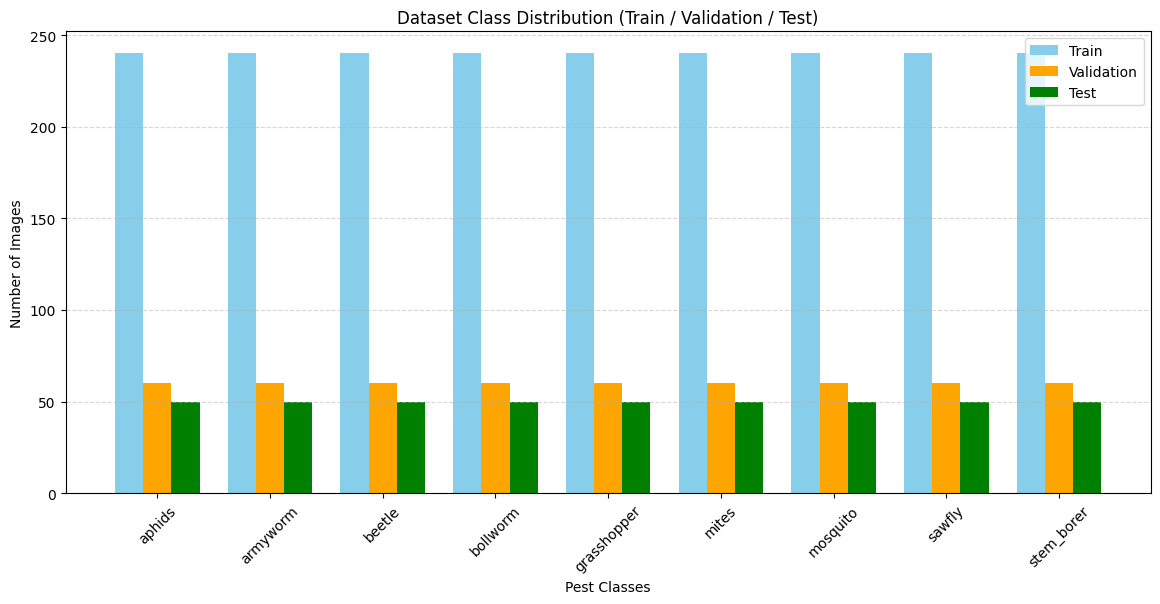

In [ ]:
classes = list(train_counts.keys())

train_values = np.array(list(train_counts.values()))
val_values   = np.array(list(val_counts.values()))
test_values  = np.array(list(test_counts.values()))

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, train_values, width, label='Train', color='skyblue')
plt.bar(x, val_values, width, label='Validation', color='orange')
plt.bar(x + width, test_values, width, label='Test', color='green')

plt.xticks(x, classes, rotation=45)
plt.title("Dataset Class Distribution (Train / Validation / Test)")
plt.xlabel("Pest Classes")
plt.ylabel("Number of Images")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

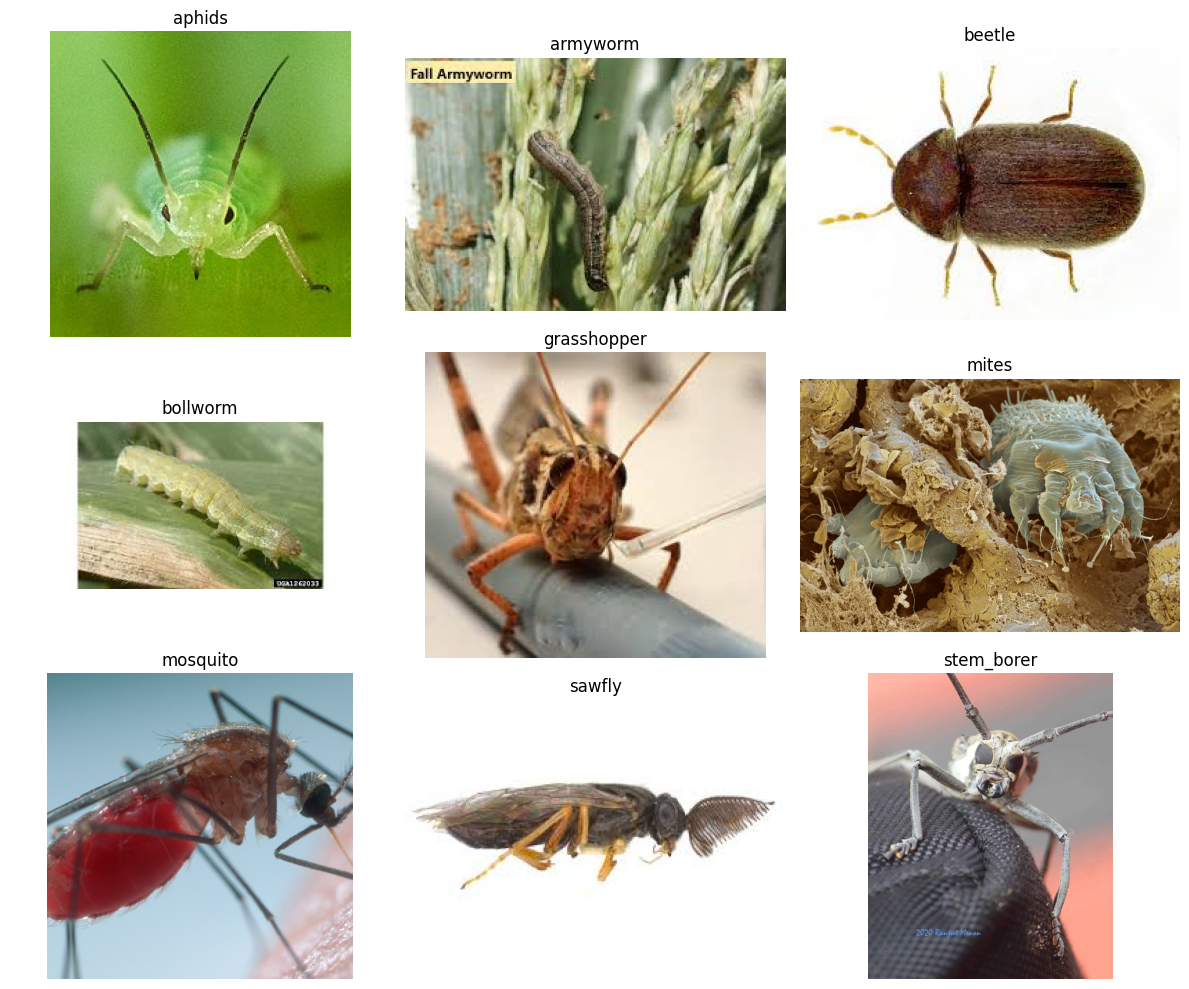

In [ ]:
from PIL import Image
plt.figure(figsize=(12,10))

for i, cls in enumerate(class_names[:9]):
    class_path = os.path.join(train_dir, cls)

    if len(os.listdir(class_path)) == 0:
        continue

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

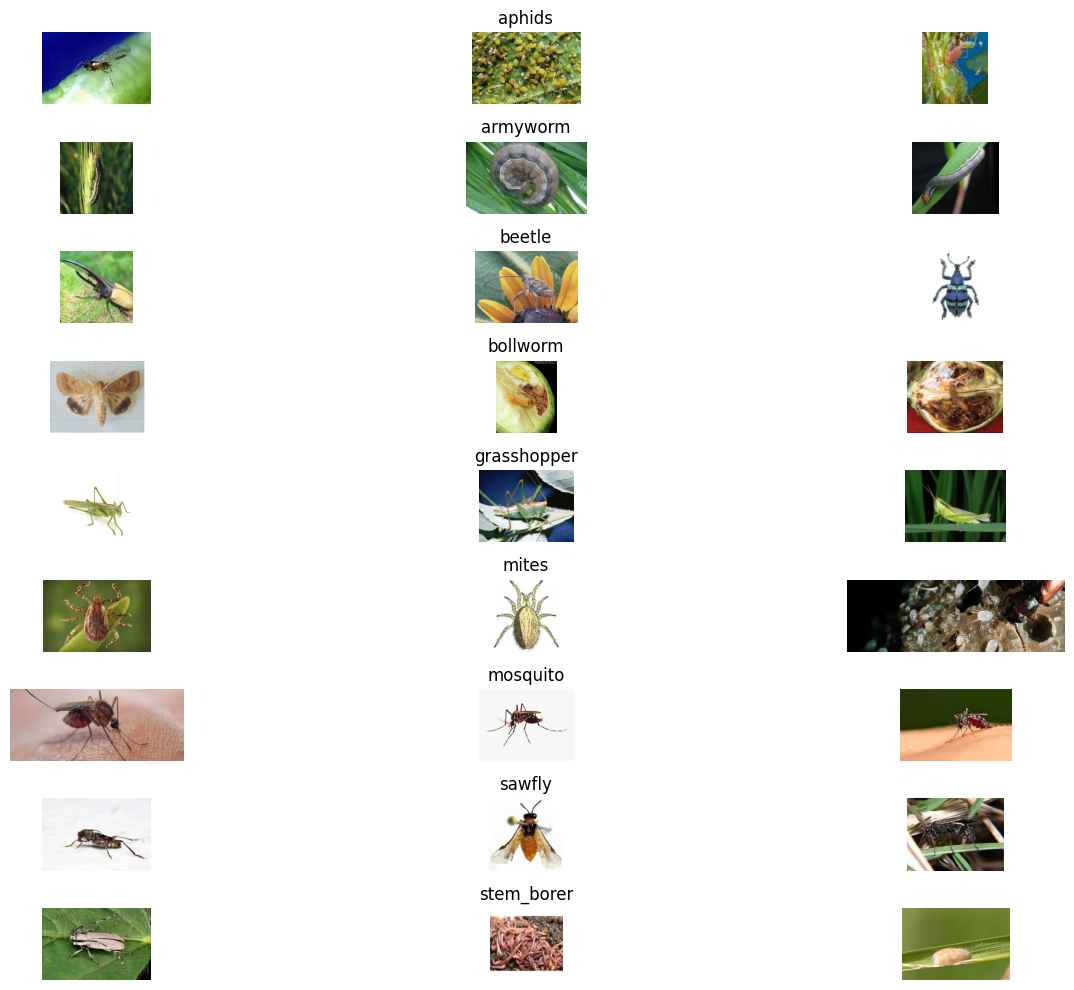

In [ ]:
plt.figure(figsize=(15, 10))

for i, cls in enumerate(class_names):
    class_path = os.path.join(train_dir, cls)

    images = os.listdir(class_path)

    if len(images) == 0:
        continue

    for j in range(3):
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path).convert("RGB")

        plt.subplot(len(class_names), 3, i * 3 + j + 1)
        plt.imshow(img)
        plt.axis("off")

        if j == 1:
            plt.title(cls)

plt.tight_layout()
plt.show()

In [ ]:
sample_img = Image.open(img_path)
print("Image size:", sample_img.size)

Image size: (274, 184)


**Data Pre-processing**

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True,

    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2160 images belonging to 9 classes.
Found 540 images belonging to 9 classes.
Found 450 images belonging to 9 classes.


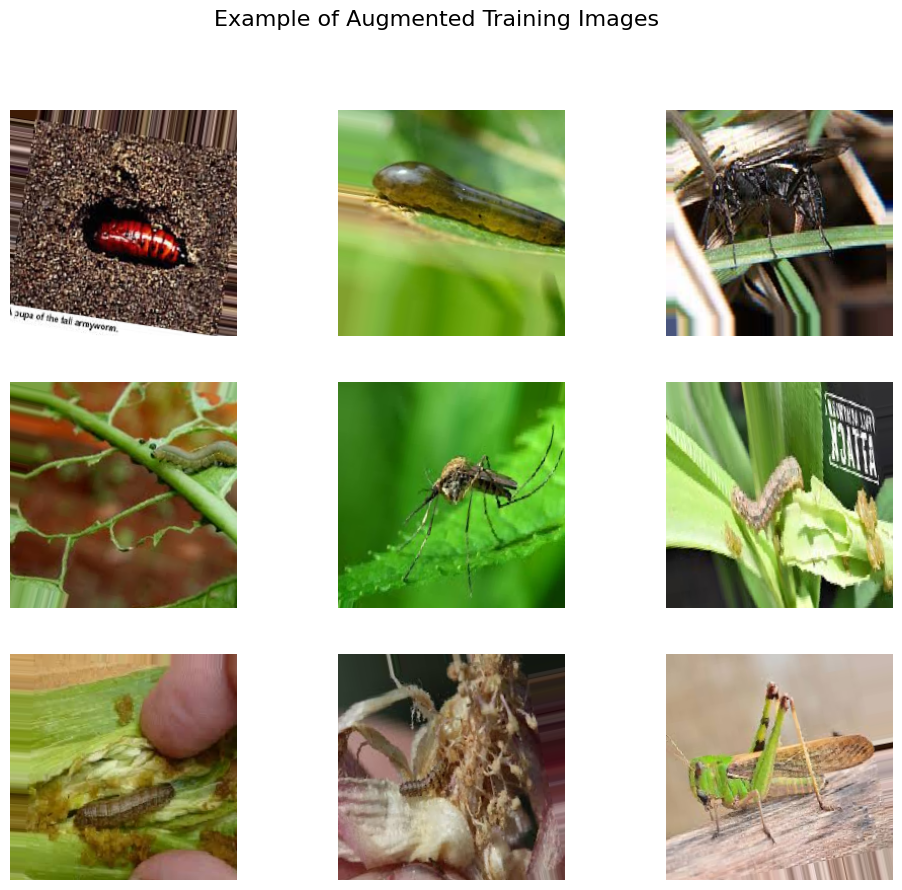

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Example of Augmented Training Images", fontsize=16)
plt.show()

**CNN from Strach**

In [ ]:
from tensorflow.keras import layers, models, optimizers

def build_baseline_cnn(input_shape, num_classes):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation='relu'))

    model.add(layers.Dense(64, activation='relu'))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 9

baseline_model = build_baseline_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES
)

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,905 (659.79 KB)

 Trainable params: 168,457 (658.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 413s 6s/step - accuracy: 0.1843 - loss: 2.1432 - val_accuracy: 0.1593 - val_loss: 2.1531
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.2213 - loss: 2.0775 - val_accuracy: 0.1389 - val_loss: 2.2508
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.2537 - loss: 1.9996 - val_accuracy: 0.1426 - val_loss: 2.4683
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 405s 6s/step - accuracy: 0.2731 - loss: 1.9729 - val_accuracy: 0.1944 - val_loss: 2.0678
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 408s 6s/step - accuracy: 0.2972 - loss: 1.8932 - val_accuracy: 0.2444 - val_loss: 2.0029
Epoch 6/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.2995 - loss: 1.8741 - val_accuracy: 0.2907 - val_loss: 1.9485
Epoch 7/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 403s 6s/step - accuracy: 0.3218 - loss: 1.8564 - val_accuracy: 0.2593 - val_loss: 2.0720
Epoch 8/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.3398 - loss: 1.7770 - val_accuracy: 0.2111 - v

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.48472222685813904
Final Validation Accuracy: 0.4481481611728668


In [ ]:
test_loss, cnn_acc = baseline_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", cnn_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4289 - loss: 1.5029
Test Loss: 1.5028729438781738
Test Accuracy: 0.42888888716697693


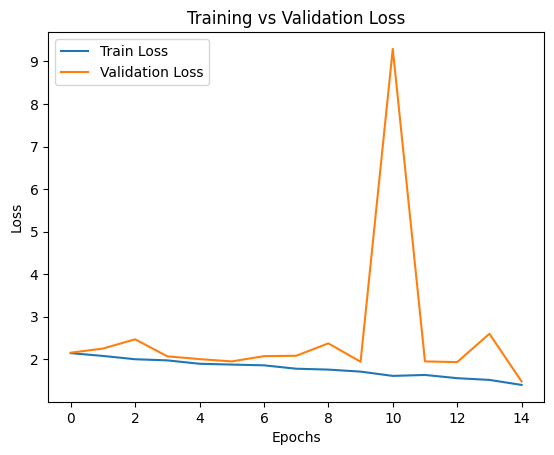

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

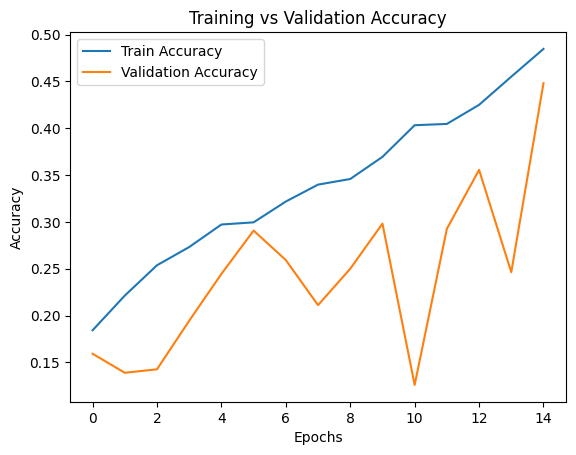

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = baseline_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

print(classification_report(y_true, y_pred_classes))

17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        60
           1       0.57      0.42      0.48        60
           2       0.86      0.42      0.56        60
           3       0.33      0.70      0.44        60
           4       0.29      0.27      0.28        60
           5       0.45      0.48      0.46        60
           6       0.91      0.65      0.76        60
           7       0.60      0.35      0.44        60
           8       0.23      0.27      0.24        60

    accuracy                           0.45       540
   macro avg       0.52      0.45      0.46       540
weighted avg       0.52      0.45      0.46       540



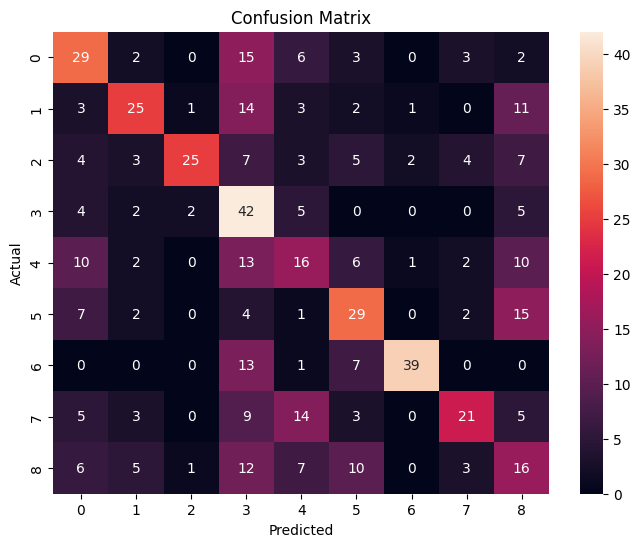

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


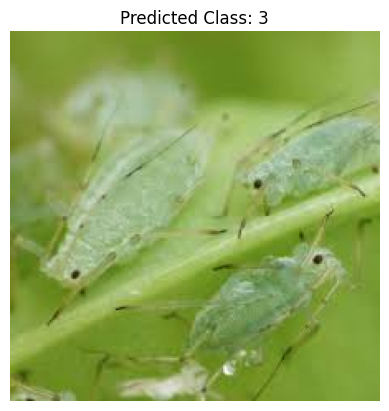

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/AI_ML_finalassignment/pest/test.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = baseline_model.predict(img_array)
pred_class = np.argmax(pred)

plt.imshow(img)
plt.title(f"Predicted Class: {pred_class}")
plt.axis('off')
plt.show()

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4289 - loss: 1.5029
Test Accuracy: 0.42888888716697693
Test Loss: 1.5028729438781738
Final Training Accuracy: 0.48472222685813904
Final Validation Accuracy: 0.4481481611728668


**Deeper CNN**

In [ ]:
from tensorflow.keras import layers, models, optimizers

def build_deeper_cnn(input_shape, num_classes):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 9

deeper_model = build_deeper_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES
)

deeper_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 256)            │         1,02

 Total params: 686,377 (2.62 MB)

 Trainable params: 684,201 (2.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_deep = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1077s 16s/step - accuracy: 0.1579 - loss: 3.0045 - val_accuracy: 0.1111 - val_loss: 2.2374
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1109s 16s/step - accuracy: 0.1954 - loss: 2.6607 - val_accuracy: 0.1111 - val_loss: 2.4099
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1072s 16s/step - accuracy: 0.2417 - loss: 2.4442 - val_accuracy: 0.1093 - val_loss: 2.4798
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1069s 16s/step - accuracy: 0.2639 - loss: 2.3290 - val_accuracy: 0.1759 - val_loss: 2.4567
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1066s 16s/step - accuracy: 0.2653 - loss: 2.3026 - val_accuracy: 0.1722 - val_loss: 2.3881
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1077s 16s/step - accuracy: 0.2843 - loss: 2.2183 - val_accuracy: 0.2148 - val_loss: 2.3089


In [ ]:
deep_loss, deep_acc = deeper_model.evaluate(test_generator)
print("Deep CNN Accuracy:", deep_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.1111 - loss: 2.2374
Deep CNN Accuracy: 0.1111111119389534


In [ ]:
import time

baseline_time = time.time() - start

print("Baseline training time:", baseline_time)

NameError: name 'start' is not defined

In [ ]:

deep_time = time.time() - start

print("Deeper model training time:", deep_time)

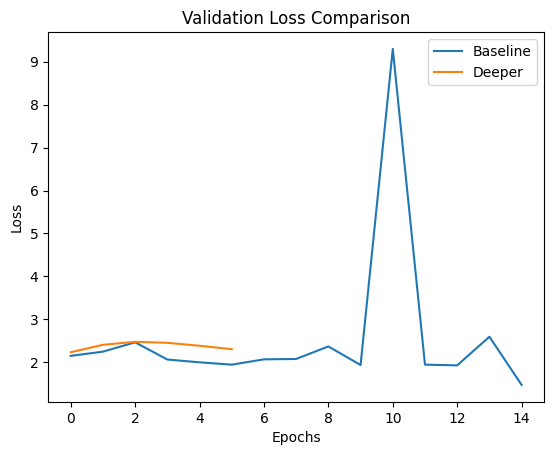

In [ ]:
plt.plot(history.history['val_loss'], label='Baseline')
plt.plot(history_deep.history['val_loss'], label='Deeper')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

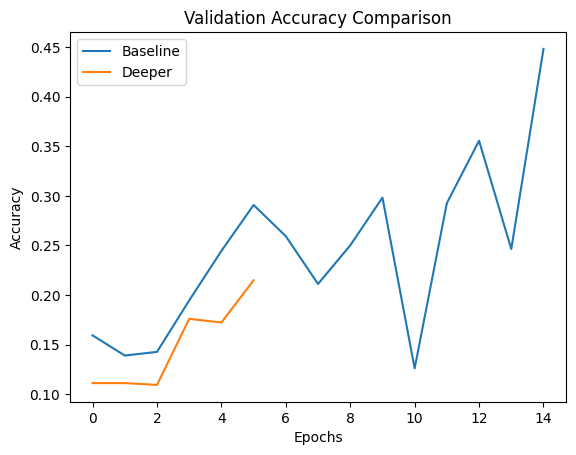

In [ ]:
plt.plot(history.history['val_accuracy'], label='Baseline')
plt.plot(history_deep.history['val_accuracy'], label='Deeper')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

val_generator.reset()

y_pred = deeper_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

print(classification_report(y_true, y_pred_classes))

17/17 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.00      0.00      0.00        60
           2       0.00      0.00      0.00        60
           3       0.00      0.00      0.00        60
           4       0.00      0.00      0.00        60
           5       0.00      0.00      0.00        60
           6       0.11      1.00      0.20        60
           7       0.00      0.00      0.00        60
           8       0.00      0.00      0.00        60

    accuracy                           0.11       540
   macro avg       0.01      0.11      0.02       540
weighted avg       0.01      0.11      0.02       540



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


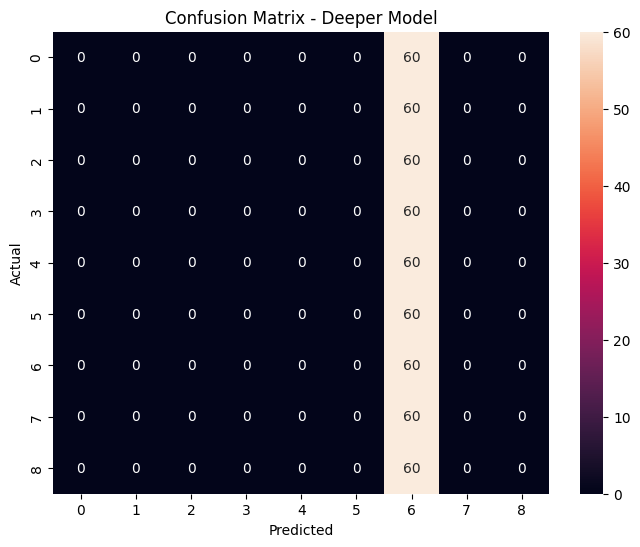

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Deeper Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from tensorflow.keras import optimizers

deeper_model_sgd = build_deeper_cnn((224,224,3), 9)

deeper_model_sgd.compile(
    optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1076s 16s/step - accuracy: 0.1602 - loss: 2.6782 - val_accuracy: 0.1574 - val_loss: 12.5471
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1077s 16s/step - accuracy: 0.2139 - loss: 2.2124 - val_accuracy: 0.1370 - val_loss: 3.3655
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1077s 16s/step - accuracy: 0.2227 - loss: 2.1126 - val_accuracy: 0.1704 - val_loss: 2.5771
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1069s 16s/step - accuracy: 0.2565 - loss: 2.0788 - val_accuracy: 0.2833 - val_loss: 1.9821
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1069s 16s/step - accuracy: 0.2440 - loss: 2.0342 - val_accuracy: 0.2778 - val_loss: 1.9833
Epoch 6/15
 1/68 ━━━━━━━━━━━━━━━━━━━━ 17:33 16s/step - accuracy: 0.2188 - loss: 2.1976

In [ ]:
plt.plot(history_deep.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model_no_dropout = build_deeper_cnn((224,224,3), 9)


In [ ]:
print("Baseline time:", baseline_time)
print("Deeper time:", deep_time)

print("Speed difference:", deep_time - baseline_time)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/AI_ML_finalassignment/pest/test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = deeper_model.predict(img_array)
class_idx = np.argmax(pred)

plt.imshow(img)
plt.title(f"Predicted Class: {class_idx}")
plt.axis('off')
plt.show()

**Transfer Learning**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import models
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)

output = layers.Dense(9, activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 678ms/step - accuracy: 0.1487 - loss: 2.6289 - val_accuracy: 0.2819 - val_loss: 2.1946
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 656ms/step - accuracy: 0.3021 - loss: 2.0077 - val_accuracy: 0.4938 - val_loss: 1.4753
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 653ms/step - accuracy: 0.4149 - loss: 1.6451 - val_accuracy: 0.6276 - val_loss: 1.1690
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 658ms/step - accuracy: 0.5336 - loss: 1.3738 - val_accuracy: 0.7078 - val_loss: 0.9776
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 649ms/step - accuracy: 0.5995 - loss: 1.2123 - val_accuracy: 0.7665 - val_loss: 0.8528
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 653ms/step - accuracy: 0.6562 - loss: 1.0608 - val_accuracy: 0.7860 - val_loss: 0.7629
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 651ms/step - accuracy: 0.6782 - loss: 0.9776 - val_accuracy: 0.7984 - val_loss: 0.6855
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 656ms/step - accuracy: 0.7280 - loss: 0.8617 - val_accu

In [ ]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg_finetune = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1211 - loss: 2.5825 - val_accuracy: 0.1556 - val_loss: 2.1986
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 971ms/step - accuracy: 0.1667 - loss: 2.3613 - val_accuracy: 0.1906 - val_loss: 2.1615
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2011 - loss: 2.2020 - val_accuracy: 0.2083 - val_loss: 2.1263
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 989ms/step - accuracy: 0.2511 - loss: 2.0750 - val_accuracy: 0.2506 - val_loss: 2.0828
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 970ms/step - accuracy: 0.2900 - loss: 1.9806 - val_accuracy: 0.3139 - val_loss: 2.0201
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 970ms/step - accuracy: 0.3067 - loss: 1.8574 - val_accuracy: 0.3889 - val_loss: 1.9526
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 979ms/step - accuracy: 0.3567 - loss: 1.7714 - val_accuracy: 0.4467 - val_loss: 1.8751
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 995ms/step - accuracy: 0.3522 - loss: 1.7617 - val_accuracy: 

In [ ]:
print("\n===== MODEL COMPARISON =====")
print("CNN Accuracy :", val_acc)
print("VGG Accuracy :", vgg_acc)



===== MODEL COMPARISON =====
CNN Accuracy : 0.3177777826786041
VGG Accuracy : 0.5799999833106995


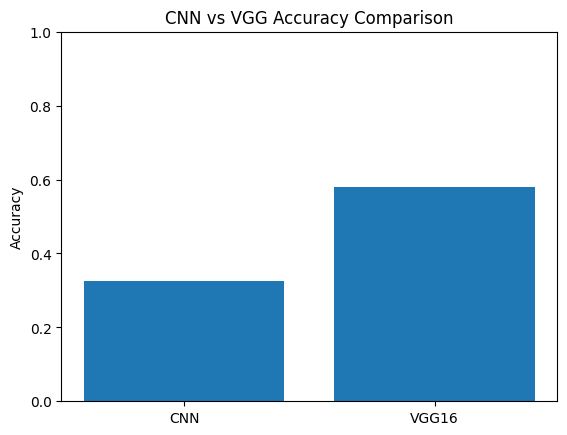

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "VGG16"]
accuracy = [cnn_acc, vgg_acc]

plt.bar(models, accuracy)
plt.title("CNN vs VGG Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model_vgg.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

print(classification_report(y_true, y_pred_classes))

57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step
              precision    recall  f1-score   support

           0       0.38      0.59      0.46       200
           1       0.70      0.44      0.54       200
           2       0.49      0.83      0.62       200
           3       0.47      0.60      0.53       200
           4       0.79      0.70      0.74       200
           5       0.74      0.80      0.76       200
           6       0.79      0.73      0.76       200
           7       0.54      0.25      0.34       200
           8       0.63      0.31      0.42       200

    accuracy                           0.58      1800
   macro avg       0.62      0.58      0.58      1800
weighted avg       0.62      0.58      0.58      1800



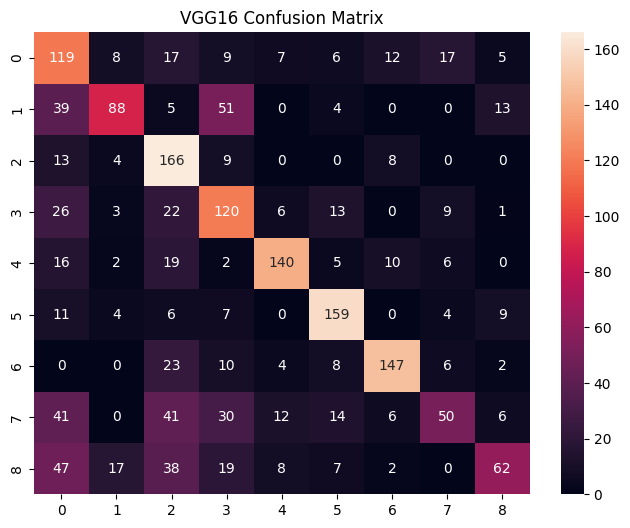

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("VGG16 Confusion Matrix")
plt.show()

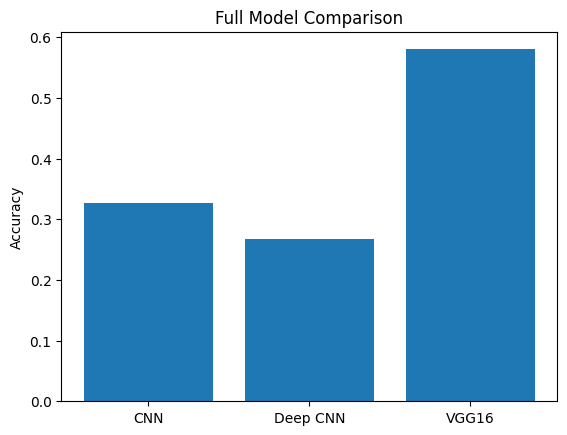

In [ ]:
models = ["CNN", "Deep CNN", "VGG16"]
accuracy = [cnn_acc, deep_acc, vgg_acc]

plt.bar(models, accuracy)
plt.title("Full Model Comparison")
plt.ylabel("Accuracy")
plt.show()